In [1]:
using GLMakie

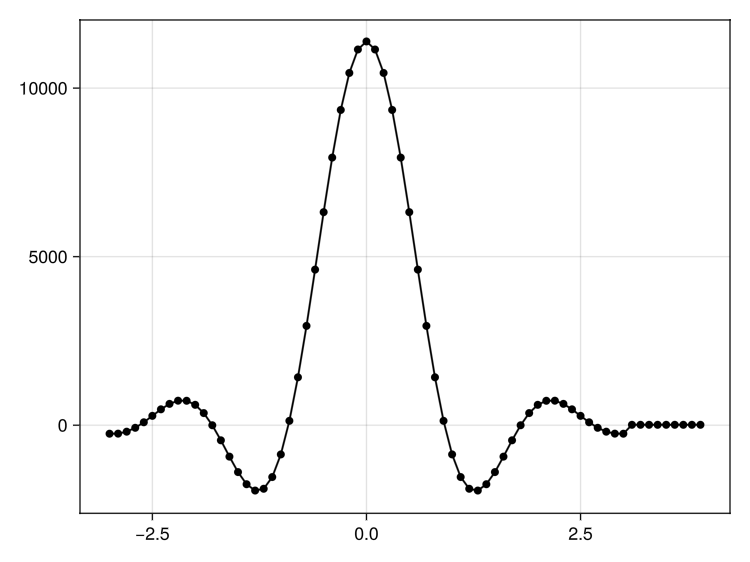

In [2]:
h0(b) = (1+b*(4/pi-1))
h1(b) = b/sqrt(2) * ( (1+2/pi)sin(pi/(4b)) + (1 - 2/pi) * cos(pi/(4*b)))
h(t,b) = t == 0 ? h0(b) : abs(t) == 1/(4*b) ? h1(b) : 
(sin(pi*t*(1-b)) + 4*b*t*cos(pi*t*(1+b)))/(pi*t*(1-(4*b*t)^2))

# span = 6, 10 samples per
ts = -3:0.1:3

# start with beta = 0.35
hs = h.(ts,0.35) 

# Normalize energy
hs = hs/sqrt(sum(hs.^2))

# Turn into Q1.15
qs = Int.(round.(hs*(2^15-1)))
RRC = zeros(Int,70)

for phase in 1:10
    for i in 1:7
    RRC[phase+(i-1)*10] = (i-1)*10+phase > 61 ? 0 : qs[(i-1)*10+phase]
    end
end
scatterlines(-3:0.1:3.9,RRC,color=:black)